<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_flavor = 1/27  # Hypothetical flavor–phase coupling


In [ ]:
def generate_flavor_triplet(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    electron = np.sin(X)
    muon     = np.sin(Y + np.pi/3)
    tau      = np.sin(X + Y + 2*np.pi/3)
    return electron, muon, tau


In [ ]:
def flavor_phase_coupling(electron, muon, tau, beta=1/27):
    grad_e_x, grad_e_y = np.gradient(electron)
    grad_m_x, grad_m_y = np.gradient(muon)
    grad_t_x, grad_t_y = np.gradient(tau)

    theta_e = np.arctan2(grad_e_y, grad_e_x)
    theta_m = np.arctan2(grad_m_y, grad_m_x)
    theta_t = np.arctan2(grad_t_y, grad_t_x)

    # Coupling terms
    coupling_em = -beta * np.sin(theta_e - theta_m)
    coupling_mt = -beta * np.sin(theta_m - theta_t)
    coupling_te = -beta * np.sin(theta_t - theta_e)

    electron += coupling_te
    muon     += coupling_em
    tau      += coupling_mt

    return electron, muon, tau


In [ ]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [ ]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Electron fidelity: 0.9695
Muon fidelity:     0.9696
Tau fidelity:      0.9697


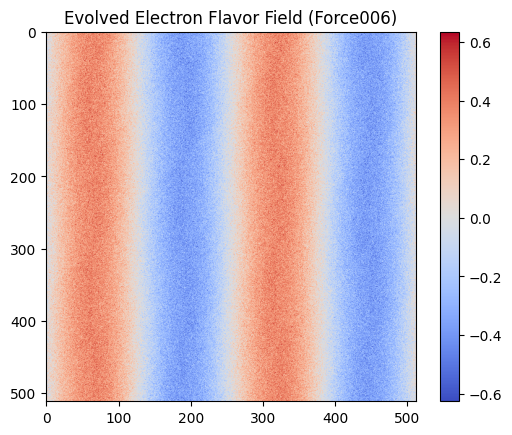

In [ ]:
electron, muon, tau = generate_flavor_triplet(grid_size)
electron_c, muon_c, tau_c = flavor_phase_coupling(electron, muon, tau, beta_flavor)

electron_e = evolve_field(electron_c, e_folds)
muon_e     = evolve_field(muon_c, e_folds)
tau_e      = evolve_field(tau_c, e_folds)

f_e = memory_fidelity(electron_c, electron_e)
f_m = memory_fidelity(muon_c, muon_e)
f_t = memory_fidelity(tau_c, tau_e)

print(f"Electron fidelity: {f_e:.4f}")
print(f"Muon fidelity:     {f_m:.4f}")
print(f"Tau fidelity:      {f_t:.4f}")

plt.imshow(electron_e, cmap='coolwarm')
plt.title("Evolved Electron Flavor Field (Force006)")
plt.colorbar()
plt.show()
